In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
import optuna
from lightgbm import early_stopping, log_evaluation
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
#Step 1. データの準備

#データ読み込み
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv") 
test= pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

train_raw = train
test_raw = test

# 基本情報
print("train shape:", train_raw.shape)
print("test shape:", test_raw.shape)

# データの先頭5行
display(train_raw.head())

# データ型・欠損値確認
train_raw.info()

# 欠損値の多い列を確認
missing = train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n欠損値の多い列(train):")
print(missing.head(20))

missing = test_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n欠損値の多い列(test):")
print(missing.head(20))

#\n は改行
#N/Aはpd.read_csvによって欠損値として扱われる

train shape: (1460, 81)
test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
#Step 2. 数値・カテゴリ列の確認

# 数値・カテゴリ列の分類
num_cols = train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train_raw.select_dtypes(exclude=[np.number]).columns.tolist()

#select_dtypes(include=[np.number])：数値型（int, float など）の列だけを抽出
#select_dtypes(exclude=[np.number])：数値型以外（object, bool, category など）の列を抽出
#.columns.tolist()：列名をリスト形式で取得

print(f"数値列: {len(num_cols)}個")
print(f"カテゴリ列: {len(cat_cols)}個")

#"f" は **f文字列（フォーマット文字列）**と呼ばれる Python の機能で、文字列の中に変数や式を埋め込むための便利な書き方
#f"..." の中に {} を使って、Pythonの式や変数を埋め込む
#従来の方法:print("数値列: " + str(len(num_cols)) + "個")

# 確認用
print("数値列サンプル:", num_cols[:10])
print("カテゴリ列サンプル:", cat_cols[:10])

数値列: 38個
カテゴリ列: 43個
数値列サンプル: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']
カテゴリ列サンプル: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


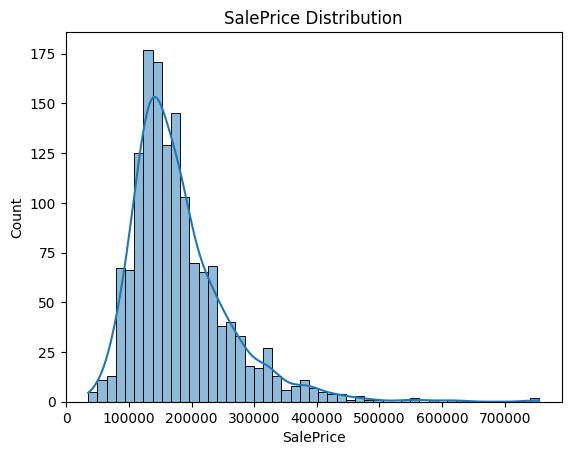

Skewness: 1.8828757597682129


In [4]:
#Step 3. SalePriceの分布を確認

sns.histplot(train_raw['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

#sns.histplot(...)：Seabornライブラリでヒストグラム（度数分布）を描画
#kde=True：カーネル密度推定（KDE）曲線を重ねて、滑らかな分布の形を表示
#plt.title(...)：グラフにタイトルを追加
#plt.show()：グラフを表示


# 歪度を確認
print("Skewness:", train_raw['SalePrice'].skew())

#.skew()：Pandasの関数で、**歪度（skewness）**を計算


In [5]:
#🎯 分布の正規化（目的変数の変換）
#なぜ必要？
#- 回帰問題では、目的変数が正規分布に近い方がモデルの学習が安定しやすい
#- 特に SalePrice のような価格データは右に歪んだ分布になりがち
#- 歪度が大きいと、モデルが高価格帯に引っ張られてしまう可能性がある
#よく使われる変換方法
#- 対数変換：np.log1p(SalePrice)
#→ 右に長い裾を圧縮し、分布を対称に近づける
#- Box-Cox変換：scipy.stats.boxcox(SalePrice)
#→ より柔軟な変換（ただし0以下の値は不可）
#注意点
#- 分類問題（例：タイタニックの Survived）では不要
# → 目的変数が2値（0 or 1）の場合、分布の正規化は意味がない

# 📈 カーネル密度推定（KDE）
# 何をするもの？
# - データの分布を滑らかな曲線で可視化する手法
# - ヒストグラムよりも連続的で自然な形を描ける
# 特徴
# - 各データ点に「カーネル関数」（通常はガウス）を置いて、全体の密度を推定
# - sns.histplot(..., kde=True) や sns.kdeplot(...) で描画可能
# - バンド幅（bandwidth）を調整することで滑らかさをコントロール
# 使いどころ
# - 目的変数や特徴量の分布を確認する際に便利
# - 外れ値や偏りの視覚的チェックに最適


SalePriceと相関の高い変数:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


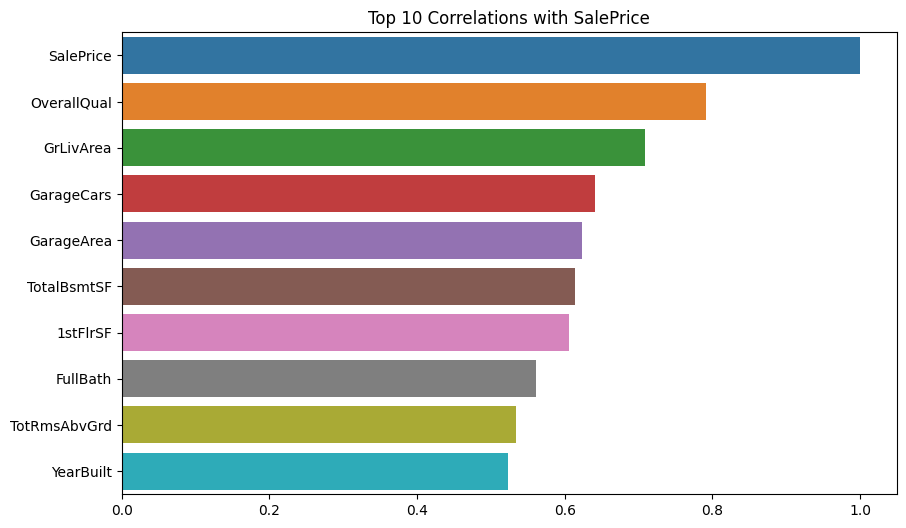

In [6]:
# Step 4. 数値列との相関を確認

corr = train_raw.corr(numeric_only=True)
top_corr = corr['SalePrice'].sort_values(ascending=False).head(10)
print("SalePriceと相関の高い変数:")
print(top_corr)

#train_raw.corr() は 数値型の列同士の相関係数（Pearson） を計算
#numeric_only=True により、数値列だけを対象にする（カテゴリ列は除外）
#corr['SalePrice']：SalePrice と他の数値列との相関係数を抽出
#.sort_values(ascending=False)：相関係数が高い順に並べる
#.head(10)：上位10個を取り出す


plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top 10 Correlations with SalePrice")
plt.show()

#top_corr.values：相関係数（x軸）
#top_corr.index：変数名（y軸）
#sns.barplot(...)：Seabornで棒グラフを描画
#plt.title(...)：グラフにタイトルを追加


In [7]:
# カテゴリ欠損をNoneで補完
test_cat_cols = test_raw.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    train_raw[col] = train_raw[col].fillna('None')
for test_col in test_cat_cols:
     test_raw[test_col] = test_raw[test_col].fillna('None')
#N/A(欠損値)をNone(文字列)で補完

# 欠損値の多い列を確認
train_missing = train_raw.isnull().sum() 
train_missing = train_missing[train_missing > 0].sort_values(ascending=False) 
print("\n欠損値の多い列(train):") 
print(train_missing.head(20))

test_missing = test_raw.isnull().sum() 
test_missing = test_missing[test_missing > 0].sort_values(ascending=False) 
print("\n欠損値の多い列(test):") 
print(test_missing.head(20))


欠損値の多い列(train):
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

欠損値の多い列(test):
LotFrontage     227
GarageYrBlt      78
MasVnrArea       15
BsmtFullBath      2
BsmtHalfBath      2
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
GarageCars        1
GarageArea        1
dtype: int64


In [8]:
# 数値欠損を補完

train_raw.loc[train_raw['GarageYrBlt'].isnull(), 'GarageYrBlt'] = 0
test_raw.loc[test_raw['GarageYrBlt'].isnull(), 'GarageYrBlt'] = 0
# すでに GarageType が "None" で補完されているので、それに合わせて "None" の場合は 0 に置き換えるのが自然
# 1. train_raw['GarageYrBlt'].isnull()
# - GarageYrBlt 列の各値が欠損かどうかを判定（True/FalseのSeriesを返す）
# 2. train_raw.loc[... , 'GarageYrBlt']
# - .loc を使って、欠損値がある行の GarageYrBlt 列を選択
# 3. = 0
# - 欠損値のあるセルに対して、0を代入

train_raw.loc[train_raw['MasVnrArea'].isnull(), 'MasVnrArea'] = 0
test_raw.loc[test_raw['MasVnrArea'].isnull(), 'MasVnrArea'] = 0
# 同じく MasVnrType が "None" の場合は、この面積も 0 にします。

train_raw['LotFrontage'] = train_raw.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
# これは**敷地の道路接面距離（フィート）**を示します。
# 周辺の土地のサイズ（LotArea）や地域（Neighborhood）に依存するため、
# ここは「Neighborhoodごとの平均値で補完」

# train の Neighborhood ごとの LotFrontage の中央値を取得
lotfrontage_medians = train_raw.groupby('Neighborhood')['LotFrontage'].median()
# test データの欠損を補完
test_raw['LotFrontage'] = test_raw.apply(
    lambda row: lotfrontage_medians[row['Neighborhood']] if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
    axis=1
)

# test_raw.apply(..., axis=1):test データの各行（row）に対して処理を適用する。axis=1 は「行方向に適用する」という意味。
# lambda row:各行（row）に対して実行する関数を定義。
# pd.isnull(row['LotFrontage']):その行の LotFrontage が欠損しているかどうかを判定。
# lotfrontage_medians[row['Neighborhood']]:その行の Neighborhood に対応する LotFrontage の中央値を取得（train から計算済み）。
# else row['LotFrontage']:欠損していない場合は元の値をそのまま使う。

missing = train_raw.isnull().sum()
print("\n欠損値の多い列(train):") 
print(missing[missing > 0])

missing = test_raw.isnull().sum()
print("\n欠損値の多い列(test):") 
print(missing[missing > 0])


欠損値の多い列(train):
Series([], dtype: int64)

欠損値の多い列(test):
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
GarageCars      1
GarageArea      1
dtype: int64


In [9]:
# BsmtFullBath      2→2件とも地下室なし→0で補完する
# BsmtHalfBath      2→2件とも地下室なし→0で補完する
# BsmtFinSF1        1→地下室なし→0で補完する
# BsmtFinSF2        1→地下室なし→0で補完する
# BsmtUnfSF         1→地下室なし→0で補完する
# TotalBsmtSF       1→地下室なし→0で補完する
# GarageCars        1→ガレージdetached→最頻値で補完
# GarageArea        1→ガレージdetached→最頻値の中央値で補完

# train データから GarageCars の最頻値（mode）を取得
garagecars_mode = train_raw['GarageCars'].mode()[0]
# test データの欠損を補完
test_raw['GarageCars'] = test_raw['GarageCars'].fillna(garagecars_mode)

# train データで GarageCars が最頻値の行に絞って、GarageArea の中央値を取得
garagearea_median = train_raw.loc[train_raw['GarageCars'] == garagecars_mode, 'GarageArea'].median()
# test データの欠損を補完
test_raw['GarageArea'] = test_raw['GarageArea'].fillna(garagearea_median)


#他を0で補完
test_raw = test_raw.fillna(0)

missing = test_raw.isnull().sum()
print("\n欠損値の多い列(test):") 
print(missing[missing > 0])


欠損値の多い列(test):
Series([], dtype: int64)


In [10]:
#カテゴリ変数エンコーディング

print(f"カテゴリ列の数: {len(cat_cols)}")
print(cat_cols)

#One-Hot Encoding

train_encoded = pd.get_dummies(train_raw, drop_first=True)
test_encoded = pd.get_dummies(test_raw, drop_first=True)

# trainとtestで列の不一致を修正
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

#.align:2つのDataFrameの列やインデックスを揃える
#join='left':trainの列構成に合わせてtestを調整（trainが基準）
# axis=1:列方向で揃える（行ではなく列）
# fill_value=0:testに存在しない列は「0」で埋める（＝そのカテゴリがtestには出現していない）
#testデータにしかない列がある場合、それは削除される（trainを学習したモデルからすれば未知のデータのため削除で正しい）


print(f"変換後のtrain形状: {train_encoded.shape}")
print(f"変換後のtest形状: {test_encoded.shape}")

#結果確認
print("trainデータ（先頭5行）:")
display(train_encoded.head())

print("\n列数確認:")
print(train_encoded.shape[1])

カテゴリ列の数: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
変換後のtrain形状: (1460, 262)
変換後のtest形状: (1459, 262)
trainデータ（先頭5行）:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False



列数確認:
262


In [11]:
# 目的変数
y = train_encoded["SalePrice"]
train_encoded.drop("SalePrice", axis=1, inplace=True)
test_encoded.drop("SalePrice", axis=1, inplace=True)


# 3. 特徴量エンジニアリング
# =====================================

# (1) 総面積: TotalSF = 1F + 2F + 地下
train_encoded["TotalSF"] = train_encoded["TotalBsmtSF"] + train_encoded["1stFlrSF"] + train_encoded["2ndFlrSF"]
test_encoded["TotalSF"]  = test_encoded["TotalBsmtSF"]  + test_encoded["1stFlrSF"]  + test_encoded["2ndFlrSF"]

# (2) 全部屋数（バス含む）
train_encoded["TotalRooms"] = train_encoded["TotRmsAbvGrd"] + train_encoded["FullBath"] + train_encoded["HalfBath"]
test_encoded["TotalRooms"]  = test_encoded["TotRmsAbvGrd"]  + test_encoded["FullBath"]  + test_encoded["HalfBath"]

# (3) 家の築年数・リフォーム年差
train_encoded["HouseAge"] = train_encoded["YrSold"] - train_encoded["YearBuilt"]
train_encoded["RemodAge"] = train_encoded["YrSold"] - train_encoded["YearRemodAdd"]
test_encoded["HouseAge"]  = test_encoded["YrSold"] - test_encoded["YearBuilt"]
test_encoded["RemodAge"]  = test_encoded["YrSold"] - test_encoded["YearRemodAdd"]

# (4) 総バス数（半分のバスを0.5で加算）
train_encoded["TotalBath"] = train_encoded["FullBath"] + (0.5 * train_encoded["HalfBath"]) + train_encoded["BsmtFullBath"] + (0.5 * train_encoded["BsmtHalfBath"])
test_encoded["TotalBath"]  = test_encoded["FullBath"]  + (0.5 * test_encoded["HalfBath"])  + test_encoded["BsmtFullBath"]  + (0.5 * test_encoded["BsmtHalfBath"])

# (5) Porch合計面積
porch_cols = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]
train_encoded["TotalPorchSF"] = train_encoded[porch_cols].sum(axis=1)
test_encoded["TotalPorchSF"]  = test_encoded[porch_cols].sum(axis=1)

# (6) 全体品質と総面積の交互項（非線形性対策）
train_encoded["Qual*SF"] = train_encoded["OverallQual"] * train_encoded["TotalSF"]
test_encoded["Qual*SF"]  = test_encoded["OverallQual"]  * test_encoded["TotalSF"]

print("特徴量作成完了。現在のtrain形状:", train_encoded.shape)
print("特徴量作成完了。現在のtest形状:", test_encoded.shape)

特徴量作成完了。現在のtrain形状: (1460, 268)
特徴量作成完了。現在のtest形状: (1459, 268)



=== SalePriceとの相関上位10 ===
SalePrice      1.000000
Qual*SF        0.856148
OverallQual    0.790982
TotalSF        0.782260
GrLivArea      0.708624
GarageCars     0.640409
TotalBath      0.631731
GarageArea     0.623431
TotalBsmtSF    0.613581
1stFlrSF       0.605852
TotalRooms     0.600357
FullBath       0.560664
Name: SalePrice, dtype: float64


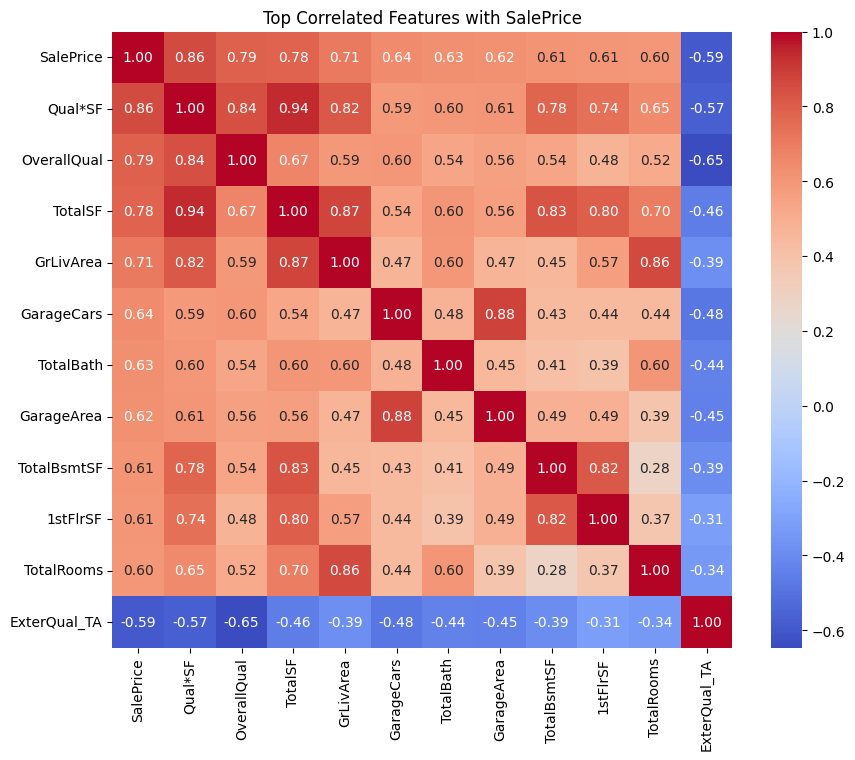

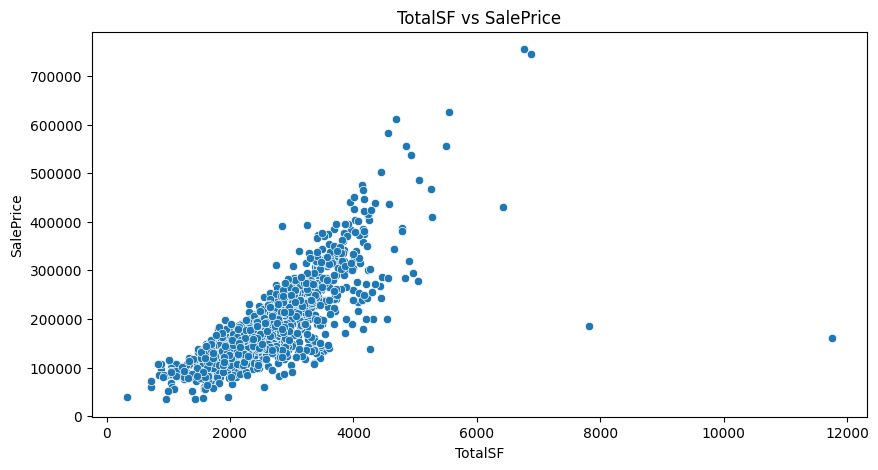

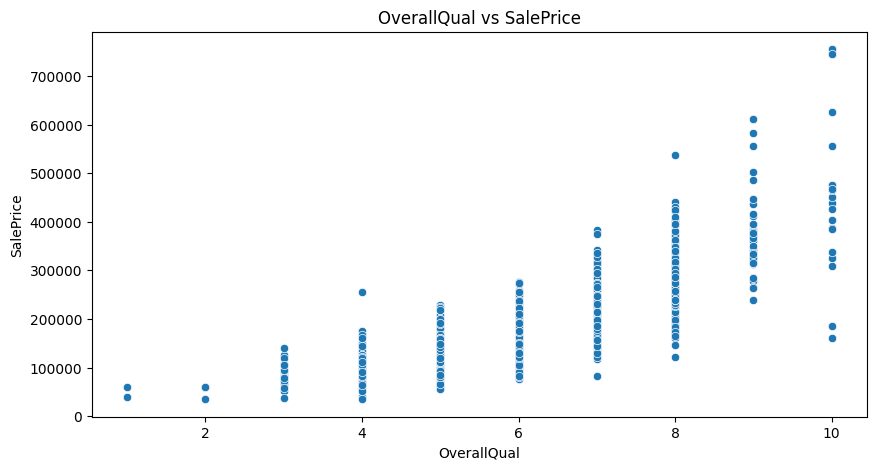

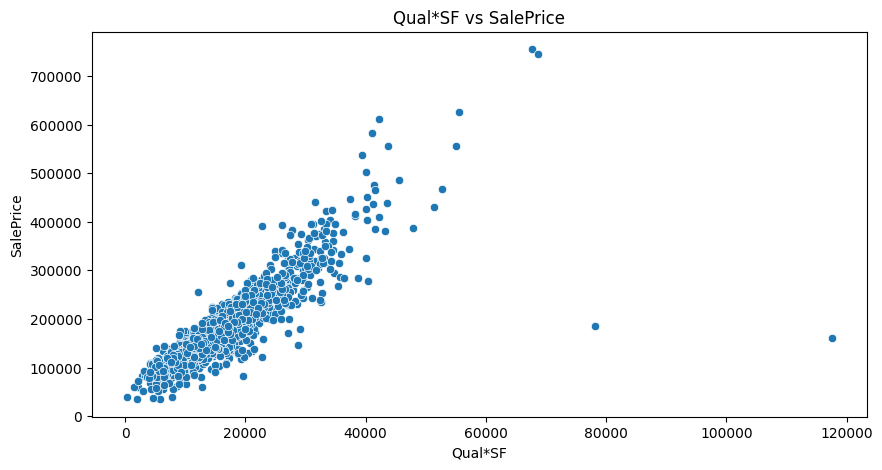

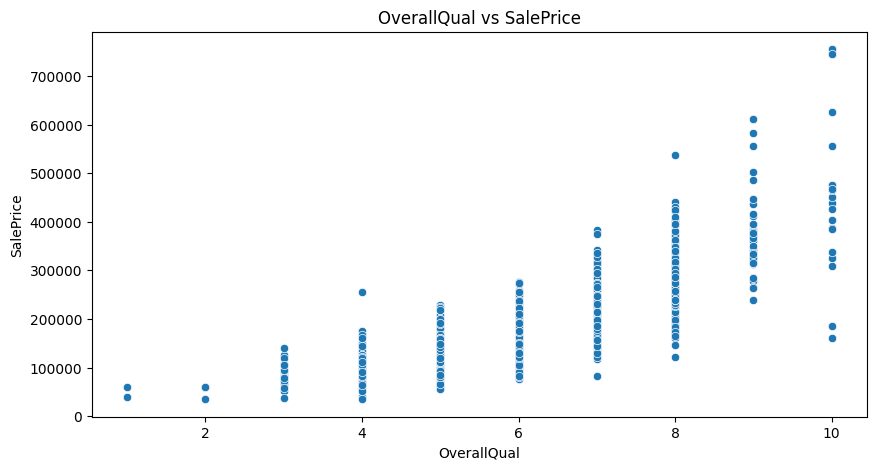

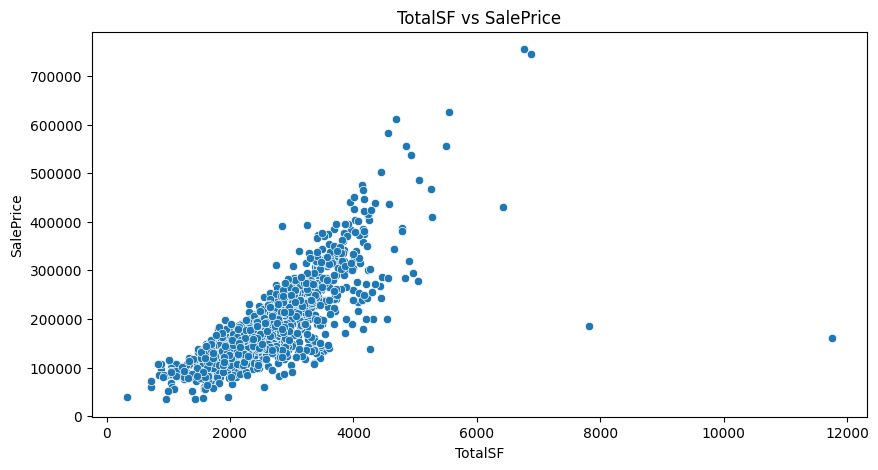

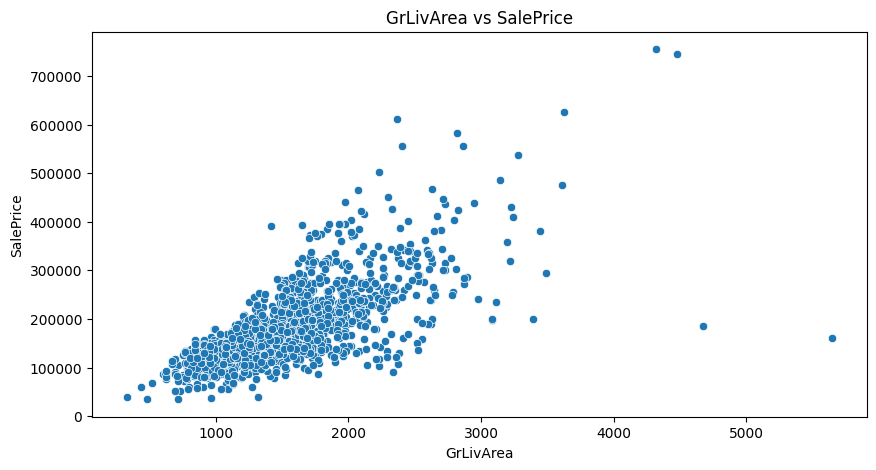

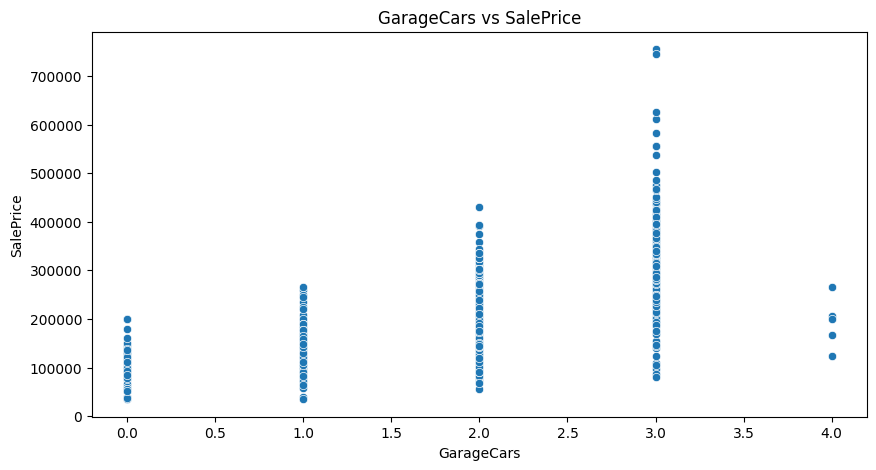

In [12]:
corr_df = pd.concat([train_encoded, y], axis=1)
corr = corr_df.corr()["SalePrice"].sort_values(ascending=False)

print("\n=== SalePriceとの相関上位10 ===")
print(corr.head(12))

# 相関ヒートマップ（上位変数のみ表示）
top_corr_features = corr.abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df[top_corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top Correlated Features with SalePrice")
plt.show()
#  sns.heatmap(corr_df[top_corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
# - corr_df[top_corr_features]：相関の高い特徴量だけを抽出。
# - .corr()：それらの特徴量同士の相関係数を計算。
# - sns.heatmap(...)：Seaborn でヒートマップを描画。
# - annot=True：セル内に数値を表示。
# - fmt=".2f"：小数点2桁で表示。
# - cmap="coolwarm"：色のグラデーション（青〜赤）で相関の強弱を表現。


# 散布図で代表的な関係を見る
plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["TotalSF"], y=y)
plt.title("TotalSF vs SalePrice")
plt.show()
# - Seaborn の scatterplot 関数で散布図を描画

plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["OverallQual"], y=y)
plt.title("OverallQual vs SalePrice")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["Qual*SF"], y=y)
plt.title("Qual*SF vs SalePrice")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["OverallQual"], y=y)
plt.title("OverallQual vs SalePrice")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["TotalSF"], y=y)
plt.title("TotalSF vs SalePrice")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["GrLivArea"], y=y)
plt.title("GrLivArea vs SalePrice")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=train_encoded["GarageCars"], y=y)
plt.title("GarageCars vs SalePrice")
plt.show()


In [13]:
# 欠損の再チェック
print("欠損数（train）:", train_encoded.isnull().sum().sum())
print("欠損数（test）:", test_encoded.isnull().sum().sum())

欠損数（train）: 0
欠損数（test）: 0


In [14]:
# 学習用データ分割
X_train, X_val, y_train, y_val = train_test_split(train_encoded, y, test_size=0.2, random_state=42)



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4382
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 177
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 181441.541952
Validation RMSE: 27609.3691


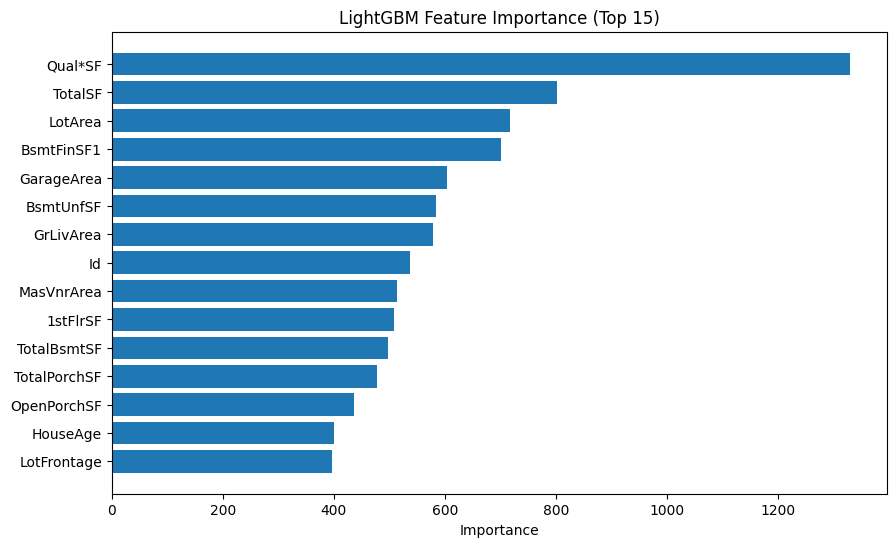

,Feature,Importance
267,Qual*SF,1330
261,TotalSF,802
3,LotArea,717
9,BsmtFinSF1,701
27,GarageArea,604
11,BsmtUnfSF,584
16,GrLivArea,579
0,Id,538
8,MasVnrArea,514
13,1stFlrSF,509


In [15]:
# LightGBM ベースモデル構築

# --- 1. 特徴量と目的変数の分離 ---

#前回分離済み

# --- 2. データ分割（train/valid）---

#前回分割済み

# --- 3. LightGBMモデル作成 ---
lgb_model = lgb.LGBMRegressor(
    random_state=42,
    objective="regression",
    n_estimators=500,
    learning_rate=0.05
)

#objective:LightGBM の目的関数（タスクの種類）
# - 'regression' → 連続値を予測する回帰問題（例：住宅価格、売上予測など）
# - 'binary' → 2値分類（例：スパムか否か）
# - 'multiclass' → 多クラス分類（例：品種分類）

# --- 4. 学習 ---
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=callbacks
)

# eval_metric="rmse"
# - 説明：評価指標としてRMSE（Root Mean Squared Error）を使用。
# - 役割：予測値と実際の値の誤差を測定する指標。値が小さいほど精度が高い。
# - 補足：回帰問題ではRMSEがよく使われます。- 複数指定も可能（例：["rmse", "mae"]）
# early_stopping_rounds=50
# - 説明：50回連続で評価指標が改善されなかったら学習を停止。
# - 役割：過学習を防ぎ、無駄な計算を省く。
# - 補足：検証データでの性能が向上しないなら、それ以上学習しても意味がないという判断。
# verbose=False
# - 説明：学習中のログ出力を抑制。
# - 役割：コンソールを静かに保ちたいときに便利。
# - 補足：Trueにすると各イテレーションの評価結果が表示されます。

# --- 5. 予測とスコア計算 ---
y_pred = lgb_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.4f}")

# --- 6. 特徴量重要度の可視化(dataframe形式) ---
feature_imp = pd.DataFrame({
    'Feature': train_encoded.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp['Feature'].head(15)[::-1], feature_imp['Importance'].head(15)[::-1])
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance (Top 15)")
plt.show()

feature_imp.head(15)

In [16]:
#OptunaによるLightGBMハイパーパラメータチューニング

# --- 1. 必要なライブラリ ---

# --- 2. 目的関数（Optunaが呼び出す） ---
def objective_gbm(trial):
#Optuna が呼び出す関数で、1回の試行（trial）で使うパラメータを決めてモデルを学習し、評価指標を返す

    # チューニング対象パラメータ
    param_gbm = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'random_state': 42,
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
    }

    # モデル作成・学習
    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=False)]
    
    model_gbm = lgb.LGBMRegressor(**param_gbm, n_estimators=2000, verbose=-1)
    model_gbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=callbacks
    )
#- n_estimators=2000：最大2000ツリーまで学習。ただし early_stopping により途中で止まる可能性あり。
   
    # 予測と評価
    preds = model_gbm.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)
    return rmse
#- squared=False により RMSE（平方根誤差）を返す
#squared=False を指定することで、わざわざ np.sqrt() を使わなくても RMSE を直接取得できる

# --- 3. チューニング実行 ---
study_gbm = optuna.create_study(direction='minimize')
study_gbm.optimize(objective_gbm, n_trials=30)
# - direction='minimize'：RMSE を小さくする方向で探索。
# - n_trials=30：30回の試行で最適なパラメータを探す。


# --- 4. 結果表示 ---
print('Best RMSE:', study_gbm.best_value)
print('Best params:', study_gbm.best_params)

# --- 5. ベストパラメータで再学習 ---
best_params_gbm = study_gbm.best_params
best_model_gbm = lgb.LGBMRegressor(**best_params_gbm, n_estimators=2000,random_state=42)
best_model_gbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=callbacks
)

# --- 6. 最終評価 ---
preds_gbm = best_model_gbm.predict(X_val)
rmse_final_gbm = mean_squared_error(y_val, preds_gbm, squared=False)
print(f'\nFinal Validation RMSE: {rmse_final_gbm:.4f}')



[I 2025-10-17 16:15:34,153] A new study created in memory with name: no-name-28f58d4d-b35e-43a7-80ca-a1cc76c056b6
[I 2025-10-17 16:15:36,148] Trial 0 finished with value: 33540.56537717108 and parameters: {'num_leaves': 117, 'max_depth': 8, 'learning_rate': 0.0067395206975308765, 'min_child_samples': 64, 'subsample': 0.7209106814217426, 'colsample_bytree': 0.6351258488815958, 'reg_alpha': 0.138092822231061, 'reg_lambda': 0.8417762255970506}. Best is trial 0 with value: 33540.56537717108.
[I 2025-10-17 16:15:36,420] Trial 1 finished with value: 32505.26025968636 and parameters: {'num_leaves': 140, 'max_depth': 11, 'learning_rate': 0.19845599887494733, 'min_child_samples': 95, 'subsample': 0.8043580230128092, 'colsample_bytree': 0.5260503492344524, 'reg_alpha': 0.5476127600641301, 'reg_lambda': 0.5646874561913977}. Best is trial 1 with value: 32505.26025968636.
[I 2025-10-17 16:15:37,010] Trial 2 finished with value: 28585.918318963013 and parameters: {'num_leaves': 178, 'max_depth': 6, 

Best RMSE: 24876.639156084282
Best params: {'num_leaves': 96, 'max_depth': 15, 'learning_rate': 0.02089736242647604, 'min_child_samples': 13, 'subsample': 0.9995200139150814, 'colsample_bytree': 0.713748890913074, 'reg_alpha': 0.39481794668364695, 'reg_lambda': 0.0017312295659995536}

Final Validation RMSE: 24876.6392


In [17]:
#OptunaによるXGBoostハイパーパラメータチューニング

# --- 1. 必要なライブラリ ---

# --- 2. 目的関数（Optunaが呼び出す） ---
def objective_xgb(trial):
#Optuna が呼び出す関数で、1回の試行（trial）で使うパラメータを決めてモデルを学習し、評価指標を返す

    # チューニング対象パラメータ
    param_xgb = {
        'n_estimators': 5000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42
    }

    # モデル作成・学習
    model_xgb = xgb.XGBRegressor(**param_xgb)
    model_xgb.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              early_stopping_rounds=100,
              verbose=False)
   
    # 予測と評価
    preds_xgb = model_xgb.predict(X_val)
    rmse = mean_squared_error(y_val, preds_xgb, squared=False)
    return rmse
#- squared=False により RMSE（平方根誤差）を返す
#squared=False を指定することで、わざわざ np.sqrt() を使わなくても RMSE を直接取得できる

# --- 3. チューニング実行 ---
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=30)
# - direction='minimize'：RMSE を小さくする方向で探索。
# - n_trials=30：30回の試行で最適なパラメータを探す。


# --- 4. 結果表示 ---
print('Best RMSE:', study_xgb.best_value)
print('Best params:', study_xgb.best_params)

# --- 5. ベストパラメータで再学習 ---
best_params_xgb = study_xgb.best_params
best_model_xgb = xgb.XGBRegressor(**best_params_xgb,
    n_estimators=5000,  # ← 再度明示的に設定
    random_state=42)

best_model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
              early_stopping_rounds=100,
              verbose=False)

# --- 6. 最終評価 ---
preds_xgb = best_model_xgb.predict(X_val)
rmse_final_xgb = mean_squared_error(y_val, preds_xgb, squared=False)
print(f'\nFinal Validation RMSE: {rmse_final_xgb:.4f}')

[I 2025-10-17 16:16:51,326] A new study created in memory with name: no-name-e4b8b891-d082-4285-b1e0-30201aab086b
[I 2025-10-17 16:16:52,461] Trial 0 finished with value: 26684.109304220332 and parameters: {'learning_rate': 0.26827457270908384, 'max_depth': 6, 'subsample': 0.9963561151006278, 'colsample_bytree': 0.7659923812457029, 'min_child_weight': 4, 'reg_alpha': 0.3567697361256632, 'reg_lambda': 0.5439337394661424}. Best is trial 0 with value: 26684.109304220332.
[I 2025-10-17 16:16:56,747] Trial 1 finished with value: 25010.356742776457 and parameters: {'learning_rate': 0.024136825393971974, 'max_depth': 5, 'subsample': 0.7781514693216074, 'colsample_bytree': 0.5065074537250225, 'min_child_weight': 3, 'reg_alpha': 0.8600705019074453, 'reg_lambda': 0.5917336903276712}. Best is trial 1 with value: 25010.356742776457.
[I 2025-10-17 16:16:59,417] Trial 2 finished with value: 28187.15695230176 and parameters: {'learning_rate': 0.13069882819440837, 'max_depth': 8, 'subsample': 0.603014

Best RMSE: 24338.948663809246
Best params: {'learning_rate': 0.17295974588808624, 'max_depth': 5, 'subsample': 0.8517935951501114, 'colsample_bytree': 0.6632304980590706, 'min_child_weight': 6, 'reg_alpha': 0.16551894877161455, 'reg_lambda': 0.09583913499678176}

Final Validation RMSE: 24338.9487


In [18]:
#OptunaによるCatoostハイパーパラメータチューニング

# --- 1. 必要なライブラリ ---

# --- 2. 目的関数（Optunaが呼び出す） ---
def objective_cat(trial):
#Optuna が呼び出す関数で、1回の試行（trial）で使うパラメータを決めてモデルを学習し、評価指標を返す

    # チューニング対象パラメータ
    param_cat = {
        'iterations': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': 42,
        'loss_function': 'RMSE',
        'verbose': False
    }

    # モデル作成・学習
    model_cat = CatBoostRegressor(**param_cat)
    model_cat.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
   
    # 予測と評価
    preds_cat = model_cat.predict(X_val)
    rmse = mean_squared_error(y_val, preds_cat, squared=False)
    return rmse
#- squared=False により RMSE（平方根誤差）を返す
#squared=False を指定することで、わざわざ np.sqrt() を使わなくても RMSE を直接取得できる

# --- 3. チューニング実行 ---
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=30)
# - direction='minimize'：RMSE を小さくする方向で探索。
# - n_trials=30：30回の試行で最適なパラメータを探す。


# --- 4. 結果表示 ---
print('Best RMSE:', study_cat.best_value)
print('Best params:', study_cat.best_params)

# --- 5. ベストパラメータで再学習 ---
best_params_cat = study_cat.best_params
best_model_cat = CatBoostRegressor(**best_params_cat, iterations=3000,  # ← 再度明示的に設定
    random_seed=42)
best_model_cat.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
              early_stopping_rounds=100,
              verbose=False)

# --- 6. 最終評価 ---
preds_cat = best_model_cat.predict(X_val)
rmse_final_cat = mean_squared_error(y_val, preds_cat, squared=False)
print(f'\nFinal Validation RMSE: {rmse_final_cat:.4f}')

[I 2025-10-17 16:18:05,979] A new study created in memory with name: no-name-8240aef1-c8be-4d90-880f-91c25c8a6d89
[I 2025-10-17 16:18:19,588] Trial 0 finished with value: 27682.36106076396 and parameters: {'learning_rate': 0.15131169652074458, 'depth': 6, 'l2_leaf_reg': 7.555814801725222, 'bagging_temperature': 0.03846911239777129, 'border_count': 117}. Best is trial 0 with value: 27682.36106076396.
[I 2025-10-17 16:20:37,831] Trial 1 finished with value: 29936.231362123795 and parameters: {'learning_rate': 0.05948152009684971, 'depth': 10, 'l2_leaf_reg': 2.13957851582096, 'bagging_temperature': 0.40969662191786504, 'border_count': 205}. Best is trial 0 with value: 27682.36106076396.
[I 2025-10-17 16:20:58,639] Trial 2 finished with value: 27631.011306719833 and parameters: {'learning_rate': 0.20072713024526656, 'depth': 7, 'l2_leaf_reg': 1.991114249250136, 'bagging_temperature': 0.42041528829209573, 'border_count': 55}. Best is trial 2 with value: 27631.011306719833.
[I 2025-10-17 16:

Best RMSE: 25992.350393780856
Best params: {'learning_rate': 0.04067108200641876, 'depth': 4, 'l2_leaf_reg': 9.892755282498953, 'bagging_temperature': 0.20566157056194279, 'border_count': 170}

Final Validation RMSE: 26020.2531


In [19]:
# ====================================================
# 5️⃣ 結果比較
# ====================================================
rmse_results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost'],
    'Validation RMSE': [rmse_final_gbm, rmse_final_xgb, rmse_final_cat]
}).sort_values(by='Validation RMSE', ascending=True)

print("\n📊 各モデルのValidation RMSE比較:")
print(rmse_results)



📊 各モデルのValidation RMSE比較:
      Model  Validation RMSE
1   XGBoost     24338.948664
0  LightGBM     24876.639156
2  CatBoost     26020.253079


In [20]:

# ====================================================
# 6️⃣ アンサンブル（平均）
# ====================================================
ensemble_pred = (preds_gbm + preds_xgb + preds_cat) / 3
ensemble_rmse = mean_squared_error(y_val, ensemble_pred, squared=False)

print(f"\n⭐ アンサンブルモデルのValidation RMSE: {ensemble_rmse:.4f}")


# --- 重み付き平均 ---
w_ensemble_pred = (
    0.5 * preds_gbm +
    0.3 * preds_xgb +
    0.2 * preds_cat
)
w_ensemble_rmse =  mean_squared_error(y_val, w_ensemble_pred, squared=False)

print(f"\n⭐ 重み付けアンサンブルモデルのValidation RMSE: {w_ensemble_rmse:.4f}")
# ====================================================
# 7️⃣ テストデータ予測と提出ファイル作成
# ====================================================
#gbm_test_pred = best_model_gbm.predict(test_encoded)
#xgb_test_pred = best_model_xgb.predict(test_encoded)
#cat_test_pred = best_model_cat.predict(test_encoded)

# 平均アンサンブル
#ensemble_test_pred = (gbm_test_pred + xgb_test_pred + cat_test_pred) / 3

# 提出ファイル作成
#submission = pd.DataFrame({
   # 'Id': test_encoded['Id'],
  #  'SalePrice': ensemble_test_pred
#})

# submission.to_csv("submission_houseprice_update_20251016.csv", index=False)

# print("\n✅ submission_houseprice_update_20251016.csv を出力しました！")


⭐ アンサンブルモデルのValidation RMSE: 24084.1274

⭐ 重み付けアンサンブルモデルのValidation RMSE: 24041.7668


In [21]:
# ====================================================
# 7️⃣ テストデータ予測と提出ファイル作成
# ====================================================
gbm_test_pred = best_model_gbm.predict(test_encoded)
xgb_test_pred = best_model_xgb.predict(test_encoded)
cat_test_pred = best_model_cat.predict(test_encoded)

# 平均アンサンブル
w_ensemble_test_pred = (0.5*gbm_test_pred + 0.3*xgb_test_pred + 0.2*cat_test_pred) 

# 提出ファイル作成
submission = pd.DataFrame({
   'Id': test_encoded['Id'],
   'SalePrice': w_ensemble_test_pred
})

submission.to_csv("submission_houseprice_update_fixed_20251017_2.csv", index=False)

print("\n✅ submission_houseprice_update_fixed_20251017_2.csv を出力しました！")


✅ submission_houseprice_update_fixed_20251017_2.csv を出力しました！


In [22]:
# 目的変数が右に裾が長いため、対数変換して正規分布に近づける

# y = np.log1p(train_encoded["SalePrice"])
# X_train, X_val, y_train, y_val = train_test_split(train_encoded, y, test_size=0.2, random_state=42)

# 例XGB
# xgb_pred = np.expm1(xgb_model.predict(X_val))
# xgb_rmse = rmse(np.expm1(y_val), xgb_pred)
#-------------------------------------------------------------------
# 【結果】以下の通りでわずかに悪化
#log変換は、
# 価格のような「右に裾の長い分布（右偏）」を正規分布に近づけて
# モデルが外れ値の影響を受けにくくなる
# というメリットがあります。

# ただし今回の場合：
 # 前処理と特徴量エンジニアリングでかなりノイズが除去されている
 # LightGBMやXGBoostが非線形性や外れ値に強いモデル
 # （線形回帰のような“分布仮定”を持たない）
# という理由で、logをかけても性能向上がほとんど出ないどころか、
# 逆にスケーリングがやや崩れて RMSEがわずかに悪化 することがあります。
#→対数変換しない
#----------------------------------------------------------------
#変換前
# 📊 各モデルのValidation RMSE比較:
#           Model  Validation RMSE
# 0      LightGBM     25172.857563
# 1       XGBoost     25858.644620
# 2      CatBoost     26858.607661
# 3  RandomForest     29213.727080

# ⭐ アンサンブルモデルのValidation RMSE: 25313.3171

#変換後
# 📊 各モデルのValidation RMSE比較:
#       Model  Validation RMSE
# 1   XGBoost     25699.644496
# 2  CatBoost     26628.551913
# 0  LightGBM     26964.867025

# ⭐ アンサンブルモデルのValidation RMSE: 25829.1971


In [23]:
print(y_train[:5])

print(best_model_xgb.best_iteration)

print(preds_xgb.min(), preds_xgb.max())

254     145000
1066    178000
638      85000
799     175000
380     127000
Name: SalePrice, dtype: int64
194
36909.23 610967.3
